<p align="center">
  <img src="https://images.unsplash.com/photo-1516321318423-f06f85e504b3?auto=format&fit=crop&w=1600&q=85"
       width="100%" alt="Natural Language Processing">
</p>

<h1 align="center">📝 Web Intelligence and NLP-Based Sentiment Analytics</h1>

<p align="center">
  <b>Notebook 03 — NLP Preprocessing</b><br>
  Transforming Clean Web Text into NLP-Ready Data
</p>

---

## 📌 Project Overview

This notebook represents the **third stage** of the Web Intelligence and NLP-Based Sentiment Analytics project.

The cleaned textual data generated in `02_Data_Cleaning_and_EDA.ipynb` will now be transformed into a consistent, normalized, and NLP-ready representation.

The preprocessing pipeline prepares raw language for downstream **feature engineering, sentiment analysis, keyword extraction, and topic modeling**.

### 🎯 Objective

The objective is to:

- Load the cleaned text dataset
- Inspect the existing text quality
- Normalize text
- Convert text to lowercase
- Remove unnecessary noise
- Tokenize text
- Handle stopwords
- Apply lemmatization
- Evaluate stemming when required
- Generate n-grams
- Analyze word frequency
- Create basic text statistics
- Save the final NLP-ready dataset

### 🔄 NLP Pipeline

```text
🧹 Clean Text
     ↓
🔡 Lowercase
     ↓
🧽 Remove Noise
     ↓
🔤 Tokenization
     ↓
🚫 Stopword Handling
     ↓
🌱 Lemmatization
     ↓
📊 Text Statistics
     ↓
🔗 N-grams
     ↓
💾 NLP-Ready Dataset
```

## 📓 Notebook Workflow

```text
01. Import Libraries
02. Configure Project Paths
03. Load Cleaned Dataset
04. Inspect Text Data
05. Create Text Normalization Pipeline
06. Convert Text to Lowercase
07. Remove URLs
08. Remove HTML / Special Characters
09. Normalize Whitespace
10. Tokenization
11. Stopword Handling
12. Lemmatization
13. Stemming — Optional Comparison
14. Build Processed Text
15. Text Statistics
16. Word Frequency
17. N-gram Analysis
18. Compare Original vs Processed Text
19. Final NLP Validation
20. Save NLP-Ready Dataset
21. Final Summary
```

## 🧠 Why NLP Preprocessing?

Human language contains noise, variations, and words that may not be useful for every NLP task.

For example:

```text
"This Product is AMAZING!!!"
```

can be normalized into:

```text
"product amazing"
```

The exact preprocessing strategy depends on the downstream model. Therefore, preprocessing should remove genuine noise while preserving information that may be important for sentiment and context.

## 1. Import Libraries

Import the libraries required for text normalization, tokenization, stopword handling, lemmatization, statistical analysis, and visualization.

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Text Processing
import re
import string

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File & Path Management
from pathlib import Path

# Warning Control
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Download Required NLTK Resources

Download the NLTK resources required by the preprocessing pipeline.

The downloads are checked through NLTK so that the notebook can run on a new environment without manually managing each resource.

In [2]:
# ============================================================
# NLTK RESOURCE SETUP
# ============================================================

nltk_resources = {
    "punkt": "tokenizers/punkt",
    "punkt_tab": "tokenizers/punkt_tab",
    "stopwords": "corpora/stopwords",
    "wordnet": "corpora/wordnet",
    "omw-1.4": "corpora/omw-1.4"
}

for package, resource_path in nltk_resources.items():
    try:
        nltk.data.find(resource_path)
        print(f"✓ {package} is available.")
    except LookupError:
        print(f"Downloading {package}...")
        nltk.download(package, quiet=True)
        print(f"✓ {package} downloaded.")

print("NLTK resource setup completed.")

✓ punkt is available.
✓ punkt_tab is available.
✓ stopwords is available.
✓ wordnet downloaded.
✓ omw-1.4 downloaded.
NLTK resource setup completed.


## 3. Configure Project Paths

Load the cleaned dataset generated by the previous notebook and define the output path for the NLP-ready dataset.

In [3]:
# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
FINAL_DATA_DIR = DATA_DIR / "final"

CLEANED_FILE = PROCESSED_DATA_DIR / "cleaned_quotes.csv"
NLP_OUTPUT_FILE = FINAL_DATA_DIR / "nlp_ready_quotes.csv"

FINAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input  : {CLEANED_FILE}")
print(f"Output : {NLP_OUTPUT_FILE}")

Input  : D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\processed\cleaned_quotes.csv
Output : D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\final\nlp_ready_quotes.csv


## 4. Load Cleaned Dataset

Load the cleaned dataset produced by `02_Data_Cleaning_and_EDA.ipynb`.

The original cleaned text is retained in a separate column so that the effect of preprocessing can be compared later.

In [4]:
# ============================================================
# LOAD CLEANED DATA
# ============================================================

df = pd.read_csv(CLEANED_FILE)

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (100, 6)


,quote_id,quote_text,author,tags,source_url,text_length
0,1,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,Albert Einstein,"change, deep-thoughts, thinking, world",https://quotes.toscrape.com/,115
1,2,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",J.K. Rowling,"abilities, choices",https://quotes.toscrape.com/,85
2,3,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,Albert Einstein,"inspirational, life, live, miracle, miracles",https://quotes.toscrape.com/,131
3,4,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",Jane Austen,"aliteracy, books, classic, humor",https://quotes.toscrape.com/,104
4,5,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",Marilyn Monroe,"be-yourself, inspirational",https://quotes.toscrape.com/,111


## 5. Inspect Text Data

Review the text column before applying NLP transformations.

This establishes a baseline for comparing the original and processed representations.

In [5]:
# ============================================================
# TEXT INSPECTION
# ============================================================

print("Text Column Summary")
print("-" * 60)

print(f"Rows            : {len(df):,}")
print(f"Missing Text    : {df['quote_text'].isna().sum():,}")
print(f"Empty Text      : {df['quote_text'].fillna('').str.strip().eq('').sum():,}")
print(f"Unique Text     : {df['quote_text'].nunique():,}")

display(df[["quote_text"]].head(10))

Text Column Summary
------------------------------------------------------------
Rows            : 100
Missing Text    : 0
Empty Text      : 0
Unique Text     : 100


,quote_text
0,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
1,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”"
2,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
3,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”"
4,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”"
5,“Try not to become a man of success. Rather become a man of value.”
6,“It is better to be hated for what you are than to be loved for what you are not.”
7,"“I have not failed. I've just found 10,000 ways that won't work.”"
8,“A woman is like a tea bag; you never know how strong it is until it's in hot water.”
9,"“A day without sunshine is like, you know, night.”"


## 6. Preserve Original Text

Create a separate `original_text` column.

This is an important reproducibility practice because the original cleaned text should remain available even after multiple preprocessing transformations.

In [6]:
# ============================================================
# PRESERVE ORIGINAL TEXT
# ============================================================

df["original_text"] = df["quote_text"].fillna("").astype(str)

print("Original text preserved successfully.")

Original text preserved successfully.


## 7. Text Normalization

Create a reusable normalization function.

The first stage performs conservative transformations:

- Lowercasing
- URL removal
- HTML-like tag removal
- Special-character handling
- Whitespace normalization

NLP-specific operations such as stopword removal and lemmatization are applied separately so each transformation can be inspected.

In [7]:
# ============================================================
# TEXT NORMALIZATION
# ============================================================

def normalize_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Keep alphabetic words and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["normalized_text"] = df["original_text"].apply(normalize_text)

display(
    df[["original_text", "normalized_text"]].head(10)
)

,original_text,normalized_text
0,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,the world as we have created it is a process of our thinking it cannot be changed without changing our thinking
1,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",it is our choices harry that show what we truly are far more than our abilities
2,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,there are only two ways to live your life one is as though nothing is a miracle the other is as though everything is a miracle
3,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",the person be it gentleman or lady who has not pleasure in a good novel must be intolerably stupid
4,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",imperfection is beauty madness is genius and its better to be absolutely ridiculous than absolutely boring
5,“Try not to become a man of success. Rather become a man of value.”,try not to become a man of success rather become a man of value
6,“It is better to be hated for what you are than to be loved for what you are not.”,it is better to be hated for what you are than to be loved for what you are not
7,"“I have not failed. I've just found 10,000 ways that won't work.”",i have not failed ive just found ways that wont work
8,“A woman is like a tea bag; you never know how strong it is until it's in hot water.”,a woman is like a tea bag you never know how strong it is until its in hot water
9,"“A day without sunshine is like, you know, night.”",a day without sunshine is like you know night


## 8. Tokenization

Tokenization divides normalized text into individual word tokens.

Example:

```text
"product quality is amazing"
```

becomes:

```text
["product", "quality", "is", "amazing"]
```

Tokens provide the basic units required for stopword analysis, word-frequency analysis, and many machine-learning workflows.

In [8]:
# ============================================================
# TOKENIZATION
# ============================================================

df["tokens"] = df["normalized_text"].apply(
    lambda text: word_tokenize(text) if text else []
)

display(
    df[["normalized_text", "tokens"]].head(10)
)

,normalized_text,tokens
0,the world as we have created it is a process of our thinking it cannot be changed without changing our thinking,"[the, world, as, we, have, created, it, is, a, process, of, our, thinking, it, can, not, be, changed, without, changing, our, thinking]"
1,it is our choices harry that show what we truly are far more than our abilities,"[it, is, our, choices, harry, that, show, what, we, truly, are, far, more, than, our, abilities]"
2,there are only two ways to live your life one is as though nothing is a miracle the other is as though everything is a miracle,"[there, are, only, two, ways, to, live, your, life, one, is, as, though, nothing, is, a, miracle, the, other, is, as, though, everything, is, a, m..."
3,the person be it gentleman or lady who has not pleasure in a good novel must be intolerably stupid,"[the, person, be, it, gentleman, or, lady, who, has, not, pleasure, in, a, good, novel, must, be, intolerably, stupid]"
4,imperfection is beauty madness is genius and its better to be absolutely ridiculous than absolutely boring,"[imperfection, is, beauty, madness, is, genius, and, its, better, to, be, absolutely, ridiculous, than, absolutely, boring]"
5,try not to become a man of success rather become a man of value,"[try, not, to, become, a, man, of, success, rather, become, a, man, of, value]"
6,it is better to be hated for what you are than to be loved for what you are not,"[it, is, better, to, be, hated, for, what, you, are, than, to, be, loved, for, what, you, are, not]"
7,i have not failed ive just found ways that wont work,"[i, have, not, failed, ive, just, found, ways, that, wont, work]"
8,a woman is like a tea bag you never know how strong it is until its in hot water,"[a, woman, is, like, a, tea, bag, you, never, know, how, strong, it, is, until, its, in, hot, water]"
9,a day without sunshine is like you know night,"[a, day, without, sunshine, is, like, you, know, night]"


## 9. Stopword Handling

Stopwords are common words that may contribute limited information for certain NLP tasks.

Examples include:

```text
the
is
a
an
and
of
to
```

For this project, a filtered token column is created rather than destroying the original tokenized representation.

In [9]:
# ============================================================
# STOPWORD HANDLING
# ============================================================

english_stopwords = set(stopwords.words("english"))

df["filtered_tokens"] = df["tokens"].apply(
    lambda tokens: [
        token for token in tokens
        if token not in english_stopwords
    ]
)

display(
    df[["tokens", "filtered_tokens"]].head(10)
)

print(f"Number of English stopwords: {len(english_stopwords)}")

,tokens,filtered_tokens
0,"[the, world, as, we, have, created, it, is, a, process, of, our, thinking, it, can, not, be, changed, without, changing, our, thinking]","[world, created, process, thinking, changed, without, changing, thinking]"
1,"[it, is, our, choices, harry, that, show, what, we, truly, are, far, more, than, our, abilities]","[choices, harry, show, truly, far, abilities]"
2,"[there, are, only, two, ways, to, live, your, life, one, is, as, though, nothing, is, a, miracle, the, other, is, as, though, everything, is, a, m...","[two, ways, live, life, one, though, nothing, miracle, though, everything, miracle]"
3,"[the, person, be, it, gentleman, or, lady, who, has, not, pleasure, in, a, good, novel, must, be, intolerably, stupid]","[person, gentleman, lady, pleasure, good, novel, must, intolerably, stupid]"
4,"[imperfection, is, beauty, madness, is, genius, and, its, better, to, be, absolutely, ridiculous, than, absolutely, boring]","[imperfection, beauty, madness, genius, better, absolutely, ridiculous, absolutely, boring]"
5,"[try, not, to, become, a, man, of, success, rather, become, a, man, of, value]","[try, become, man, success, rather, become, man, value]"
6,"[it, is, better, to, be, hated, for, what, you, are, than, to, be, loved, for, what, you, are, not]","[better, hated, loved]"
7,"[i, have, not, failed, ive, just, found, ways, that, wont, work]","[failed, ive, found, ways, wont, work]"
8,"[a, woman, is, like, a, tea, bag, you, never, know, how, strong, it, is, until, its, in, hot, water]","[woman, like, tea, bag, never, know, strong, hot, water]"
9,"[a, day, without, sunshine, is, like, you, know, night]","[day, without, sunshine, like, know, night]"


Number of English stopwords: 198


## 10. Lemmatization

Lemmatization converts words into their dictionary/base form while considering linguistic meaning.

For example:

```text
cars → car
running → running / run depending on context and POS information
```

This notebook uses WordNet-based lemmatization as a lightweight baseline. More advanced POS-aware lemmatization can be introduced later if required.

In [10]:
# ============================================================
# LEMMATIZATION
# ============================================================

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [
        lemmatizer.lemmatize(token)
        for token in tokens
    ]


df["lemmatized_tokens"] = df["filtered_tokens"].apply(
    lemmatize_tokens
)

display(
    df[["filtered_tokens", "lemmatized_tokens"]].head(10)
)

,filtered_tokens,lemmatized_tokens
0,"[world, created, process, thinking, changed, without, changing, thinking]","[world, created, process, thinking, changed, without, changing, thinking]"
1,"[choices, harry, show, truly, far, abilities]","[choice, harry, show, truly, far, ability]"
2,"[two, ways, live, life, one, though, nothing, miracle, though, everything, miracle]","[two, way, live, life, one, though, nothing, miracle, though, everything, miracle]"
3,"[person, gentleman, lady, pleasure, good, novel, must, intolerably, stupid]","[person, gentleman, lady, pleasure, good, novel, must, intolerably, stupid]"
4,"[imperfection, beauty, madness, genius, better, absolutely, ridiculous, absolutely, boring]","[imperfection, beauty, madness, genius, better, absolutely, ridiculous, absolutely, boring]"
5,"[try, become, man, success, rather, become, man, value]","[try, become, man, success, rather, become, man, value]"
6,"[better, hated, loved]","[better, hated, loved]"
7,"[failed, ive, found, ways, wont, work]","[failed, ive, found, way, wont, work]"
8,"[woman, like, tea, bag, never, know, strong, hot, water]","[woman, like, tea, bag, never, know, strong, hot, water]"
9,"[day, without, sunshine, like, know, night]","[day, without, sunshine, like, know, night]"


## 11. Stemming — Optional Comparison

Stemming reduces words using heuristic rules and may produce stems that are not valid dictionary words.

Example:

```text
studies → studi
playing → play
```

Because stemming can be aggressive, it is treated as an **optional comparison** rather than the default preprocessing method.

For the main NLP pipeline, lemmatization will be retained.

In [11]:
# ============================================================
# STEMMING — OPTIONAL
# ============================================================

stemmer = PorterStemmer()

df["stemmed_tokens"] = df["filtered_tokens"].apply(
    lambda tokens: [
        stemmer.stem(token)
        for token in tokens
    ]
)

display(
    df[[
        "filtered_tokens",
        "stemmed_tokens",
        "lemmatized_tokens"
    ]].head(10)
)

,filtered_tokens,stemmed_tokens,lemmatized_tokens
0,"[world, created, process, thinking, changed, without, changing, thinking]","[world, creat, process, think, chang, without, chang, think]","[world, created, process, thinking, changed, without, changing, thinking]"
1,"[choices, harry, show, truly, far, abilities]","[choic, harri, show, truli, far, abil]","[choice, harry, show, truly, far, ability]"
2,"[two, ways, live, life, one, though, nothing, miracle, though, everything, miracle]","[two, way, live, life, one, though, noth, miracl, though, everyth, miracl]","[two, way, live, life, one, though, nothing, miracle, though, everything, miracle]"
3,"[person, gentleman, lady, pleasure, good, novel, must, intolerably, stupid]","[person, gentleman, ladi, pleasur, good, novel, must, intoler, stupid]","[person, gentleman, lady, pleasure, good, novel, must, intolerably, stupid]"
4,"[imperfection, beauty, madness, genius, better, absolutely, ridiculous, absolutely, boring]","[imperfect, beauti, mad, geniu, better, absolut, ridicul, absolut, bore]","[imperfection, beauty, madness, genius, better, absolutely, ridiculous, absolutely, boring]"
5,"[try, become, man, success, rather, become, man, value]","[tri, becom, man, success, rather, becom, man, valu]","[try, become, man, success, rather, become, man, value]"
6,"[better, hated, loved]","[better, hate, love]","[better, hated, loved]"
7,"[failed, ive, found, ways, wont, work]","[fail, ive, found, way, wont, work]","[failed, ive, found, way, wont, work]"
8,"[woman, like, tea, bag, never, know, strong, hot, water]","[woman, like, tea, bag, never, know, strong, hot, water]","[woman, like, tea, bag, never, know, strong, hot, water]"
9,"[day, without, sunshine, like, know, night]","[day, without, sunshin, like, know, night]","[day, without, sunshine, like, know, night]"


## 12. Build Final Processed Text

Convert the lemmatized token lists back into text.

This `processed_text` column will be the primary NLP-ready text representation for downstream feature engineering.

### Example

```text
Original:
"This Product is AMAZING!!!"

Processed:
"product amazing"
```

In [12]:
# ============================================================
# BUILD NLP-READY TEXT
# ============================================================

df["processed_text"] = df["lemmatized_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

display(
    df[[
        "original_text",
        "normalized_text",
        "processed_text"
    ]].head(10)
)

,original_text,normalized_text,processed_text
0,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,the world as we have created it is a process of our thinking it cannot be changed without changing our thinking,world created process thinking changed without changing thinking
1,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",it is our choices harry that show what we truly are far more than our abilities,choice harry show truly far ability
2,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,there are only two ways to live your life one is as though nothing is a miracle the other is as though everything is a miracle,two way live life one though nothing miracle though everything miracle
3,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",the person be it gentleman or lady who has not pleasure in a good novel must be intolerably stupid,person gentleman lady pleasure good novel must intolerably stupid
4,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",imperfection is beauty madness is genius and its better to be absolutely ridiculous than absolutely boring,imperfection beauty madness genius better absolutely ridiculous absolutely boring
5,“Try not to become a man of success. Rather become a man of value.”,try not to become a man of success rather become a man of value,try become man success rather become man value
6,“It is better to be hated for what you are than to be loved for what you are not.”,it is better to be hated for what you are than to be loved for what you are not,better hated loved
7,"“I have not failed. I've just found 10,000 ways that won't work.”",i have not failed ive just found ways that wont work,failed ive found way wont work
8,“A woman is like a tea bag; you never know how strong it is until it's in hot water.”,a woman is like a tea bag you never know how strong it is until its in hot water,woman like tea bag never know strong hot water
9,"“A day without sunshine is like, you know, night.”",a day without sunshine is like you know night,day without sunshine like know night


## 13. Text Statistics

Create basic text statistics from the NLP-ready representation.

These features help understand the size and structure of the processed corpus.

In [13]:
# ============================================================
# TEXT STATISTICS
# ============================================================

df["original_char_count"] = df["original_text"].str.len()
df["processed_char_count"] = df["processed_text"].str.len()

df["original_word_count"] = df["tokens"].apply(len)
df["processed_word_count"] = df["lemmatized_tokens"].apply(len)

text_statistics = df[
    [
        "original_char_count",
        "processed_char_count",
        "original_word_count",
        "processed_word_count"
    ]
].describe().T

display(text_statistics)

,count,mean,std,min,25%,50%,75%,max
original_char_count,100.0,122.27,133.747376,34.0,66.5,86.0,125.00,1084.0
processed_char_count,100.0,66.22,74.034196,11.0,35.0,50.0,65.25,609.0
original_word_count,100.0,23.60,25.140414,7.0,12.0,17.0,25.00,199.0
processed_word_count,100.0,10.64,11.971785,2.0,6.0,8.0,11.00,102.0


## 14. Word Frequency Analysis

Calculate the frequency of words across the complete processed corpus.

Word-frequency analysis provides a simple overview of the most common vocabulary and helps identify dominant terms before feature engineering.

In [14]:
# ============================================================
# WORD FREQUENCY
# ============================================================

all_words = [
    word
    for tokens in df["lemmatized_tokens"]
    for word in tokens
]

word_frequency = (
    pd.Series(all_words)
    .value_counts()
    .rename_axis("word")
    .reset_index(name="frequency")
)

print(f"Unique processed words: {word_frequency.shape[0]:,}")

display(word_frequency.head(20))

Unique processed words: 545


,word,frequency
0,love,24
1,life,17
2,one,17
3,make,14
4,think,14
5,never,13
6,thing,10
7,book,10
8,like,9
9,good,8


## 15. Top Word Frequency Visualization

Visualize the most frequent processed words in the corpus.

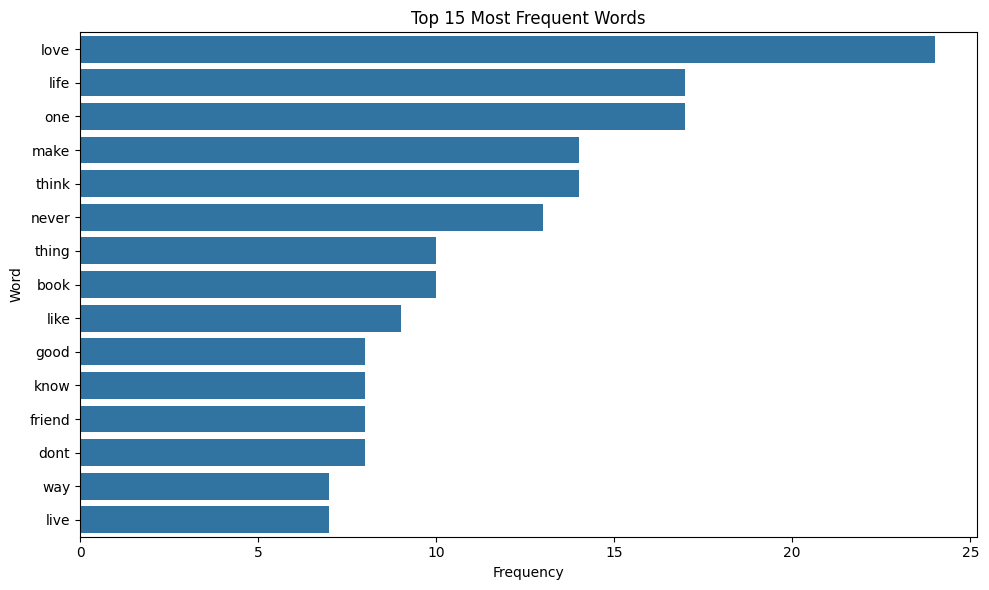

In [15]:
# ============================================================
# TOP WORD FREQUENCY VISUALIZATION
# ============================================================

top_words = word_frequency.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_words,
    x="frequency",
    y="word"
)

plt.title("Top 15 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

## 16. Generate N-grams

N-grams capture sequences of words rather than isolated terms.

### Examples

**Bigram:**

```text
machine learning
```

**Trigram:**

```text
natural language processing
```

N-grams can provide useful contextual phrases for keyword analysis and later feature engineering.

In [16]:
# ============================================================
# N-GRAM GENERATION
# ============================================================

def generate_ngrams(tokens, n):
    return [
        " ".join(tokens[i:i+n])
        for i in range(len(tokens) - n + 1)
    ]


df["bigrams"] = df["lemmatized_tokens"].apply(
    lambda tokens: generate_ngrams(tokens, 2)
)

df["trigrams"] = df["lemmatized_tokens"].apply(
    lambda tokens: generate_ngrams(tokens, 3)
)

display(
    df[["processed_text", "bigrams", "trigrams"]].head(10)
)

,processed_text,bigrams,trigrams
0,world created process thinking changed without changing thinking,"[world created, created process, process thinking, thinking changed, changed without, without changing, changing thinking]","[world created process, created process thinking, process thinking changed, thinking changed without, changed without changing, without changing t..."
1,choice harry show truly far ability,"[choice harry, harry show, show truly, truly far, far ability]","[choice harry show, harry show truly, show truly far, truly far ability]"
2,two way live life one though nothing miracle though everything miracle,"[two way, way live, live life, life one, one though, though nothing, nothing miracle, miracle though, though everything, everything miracle]","[two way live, way live life, live life one, life one though, one though nothing, though nothing miracle, nothing miracle though, miracle though e..."
3,person gentleman lady pleasure good novel must intolerably stupid,"[person gentleman, gentleman lady, lady pleasure, pleasure good, good novel, novel must, must intolerably, intolerably stupid]","[person gentleman lady, gentleman lady pleasure, lady pleasure good, pleasure good novel, good novel must, novel must intolerably, must intolerabl..."
4,imperfection beauty madness genius better absolutely ridiculous absolutely boring,"[imperfection beauty, beauty madness, madness genius, genius better, better absolutely, absolutely ridiculous, ridiculous absolutely, absolutely b...","[imperfection beauty madness, beauty madness genius, madness genius better, genius better absolutely, better absolutely ridiculous, absolutely rid..."
5,try become man success rather become man value,"[try become, become man, man success, success rather, rather become, become man, man value]","[try become man, become man success, man success rather, success rather become, rather become man, become man value]"
6,better hated loved,"[better hated, hated loved]",[better hated loved]
7,failed ive found way wont work,"[failed ive, ive found, found way, way wont, wont work]","[failed ive found, ive found way, found way wont, way wont work]"
8,woman like tea bag never know strong hot water,"[woman like, like tea, tea bag, bag never, never know, know strong, strong hot, hot water]","[woman like tea, like tea bag, tea bag never, bag never know, never know strong, know strong hot, strong hot water]"
9,day without sunshine like know night,"[day without, without sunshine, sunshine like, like know, know night]","[day without sunshine, without sunshine like, sunshine like know, like know night]"


## 17. Bigram Frequency Analysis

Calculate the most frequent two-word phrases in the processed corpus.

In [17]:
# ============================================================
# BIGRAM FREQUENCY
# ============================================================

all_bigrams = [
    bigram
    for bigrams in df["bigrams"]
    for bigram in bigrams
]

bigram_frequency = (
    pd.Series(all_bigrams)
    .value_counts()
    .rename_axis("bigram")
    .reset_index(name="frequency")
)

display(bigram_frequency.head(15))

,bigram,frequency
0,indifference opposite,3
1,fairy tale,3
2,happens drink,3
3,live life,2
4,life one,2
5,become man,2
6,youre going,2
7,going mess,2
8,come go,2
9,best friend,2


## 18. Trigram Frequency Analysis

Calculate the most frequent three-word phrases in the processed corpus.

In [18]:
# ============================================================
# TRIGRAM FREQUENCY
# ============================================================

all_trigrams = [
    trigram
    for trigrams in df["trigrams"]
    for trigram in trigrams
]

trigram_frequency = (
    pd.Series(all_trigrams)
    .value_counts()
    .rename_axis("trigram")
    .reset_index(name="frequency")
)

display(trigram_frequency.head(15))

,trigram,frequency
0,youre going mess,2
1,youll never find,2
2,intelligent read fairy,2
3,read fairy tale,2
4,world created process,1
5,created process thinking,1
6,process thinking changed,1
7,thinking changed without,1
8,changed without changing,1
9,without changing thinking,1


## 19. Compare Original and Processed Text

Compare the original cleaned text with the normalized and NLP-processed representations.

This step makes the preprocessing effect transparent and helps identify whether useful information has been removed unintentionally.

In [19]:
# ============================================================
# BEFORE vs AFTER COMPARISON
# ============================================================

comparison_df = df[
    [
        "original_text",
        "normalized_text",
        "processed_text"
    ]
].head(10)

display(comparison_df)

,original_text,normalized_text,processed_text
0,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,the world as we have created it is a process of our thinking it cannot be changed without changing our thinking,world created process thinking changed without changing thinking
1,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",it is our choices harry that show what we truly are far more than our abilities,choice harry show truly far ability
2,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,there are only two ways to live your life one is as though nothing is a miracle the other is as though everything is a miracle,two way live life one though nothing miracle though everything miracle
3,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",the person be it gentleman or lady who has not pleasure in a good novel must be intolerably stupid,person gentleman lady pleasure good novel must intolerably stupid
4,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",imperfection is beauty madness is genius and its better to be absolutely ridiculous than absolutely boring,imperfection beauty madness genius better absolutely ridiculous absolutely boring
5,“Try not to become a man of success. Rather become a man of value.”,try not to become a man of success rather become a man of value,try become man success rather become man value
6,“It is better to be hated for what you are than to be loved for what you are not.”,it is better to be hated for what you are than to be loved for what you are not,better hated loved
7,"“I have not failed. I've just found 10,000 ways that won't work.”",i have not failed ive just found ways that wont work,failed ive found way wont work
8,“A woman is like a tea bag; you never know how strong it is until it's in hot water.”,a woman is like a tea bag you never know how strong it is until its in hot water,woman like tea bag never know strong hot water
9,"“A day without sunshine is like, you know, night.”",a day without sunshine is like you know night,day without sunshine like know night


## 20. Processed Text Quality Checks

Validate the NLP-ready text before exporting it.

The checks include:

- Missing processed text
- Empty processed text
- Duplicate processed text
- Average processed word count
- Number of unique processed terms

In [20]:
# ============================================================
# NLP QUALITY CHECKS
# ============================================================

processed_missing = df["processed_text"].isna().sum()
processed_empty = df["processed_text"].str.strip().eq("").sum()
processed_duplicates = df["processed_text"].duplicated().sum()

print("NLP-READY TEXT QUALITY")
print("=" * 60)
print(f"Missing processed text   : {processed_missing:,}")
print(f"Empty processed text     : {processed_empty:,}")
print(f"Duplicate processed text : {processed_duplicates:,}")
print(f"Average word count       : {df['processed_word_count'].mean():.2f}")
print(f"Unique vocabulary        : {len(word_frequency):,}")

NLP-READY TEXT QUALITY
Missing processed text   : 0
Empty processed text     : 0
Duplicate processed text : 0
Average word count       : 10.64
Unique vocabulary        : 545


## 21. Final Dataset Schema

Review the final columns that will be retained for downstream NLP and analytical work.

Token lists and n-grams are retained because they may be useful for exploratory analysis. The `processed_text` field is the primary text representation for later modeling.

In [21]:
# ============================================================
# FINAL DATASET SCHEMA
# ============================================================

print("Final Dataset Columns")
print("-" * 60)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

print(f"\nFinal Shape: {df.shape}")

Final Dataset Columns
------------------------------------------------------------
01. quote_id
02. quote_text
03. author
04. tags
05. source_url
06. text_length
07. original_text
08. normalized_text
09. tokens
10. filtered_tokens
11. lemmatized_tokens
12. stemmed_tokens
13. processed_text
14. original_char_count
15. processed_char_count
16. original_word_count
17. processed_word_count
18. bigrams
19. trigrams

Final Shape: (100, 19)


## 22. Save NLP-Ready Dataset

Save the processed dataset to the project's `data/final/` directory.

This dataset becomes the input for the next stage:

**`04_Sentiment_Analysis.ipynb`**

The raw and cleaned datasets remain unchanged, preserving the complete data lineage.

In [22]:
# ============================================================
# SAVE NLP-READY DATASET
# ============================================================

df.to_csv(
    NLP_OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("NLP-ready dataset saved successfully.")
print(f"Output: {NLP_OUTPUT_FILE}")

NLP-ready dataset saved successfully.
Output: D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\final\nlp_ready_quotes.csv


## 23. Verify Saved Dataset

Reload the exported file to confirm that it was written successfully and can be consumed by downstream notebooks.

In [23]:
# ============================================================
# VERIFY OUTPUT
# ============================================================

nlp_df = pd.read_csv(NLP_OUTPUT_FILE)

print(f"Reloaded Shape: {nlp_df.shape}")
display(
    nlp_df[
        ["quote_id", "original_text", "processed_text"]
    ].head()
)

Reloaded Shape: (100, 19)


,quote_id,original_text,processed_text
0,1,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,world created process thinking changed without changing thinking
1,2,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",choice harry show truly far ability
2,3,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,two way live life one though nothing miracle though everything miracle
3,4,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",person gentleman lady pleasure good novel must intolerably stupid
4,5,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",imperfection beauty madness genius better absolutely ridiculous absolutely boring


## 📊 Final Summary

The text preprocessing stage has transformed the cleaned web text into an **NLP-ready dataset**.

### Completed Tasks

- Loaded cleaned web data
- Preserved original text
- Normalized text
- Converted text to lowercase
- Removed URLs and unnecessary characters
- Tokenized text
- Handled stopwords
- Applied lemmatization
- Compared optional stemming
- Built processed text
- Generated text statistics
- Analyzed word frequency
- Generated bigrams and trigrams
- Validated processed text
- Saved the NLP-ready dataset

### Output

```text
data/final/nlp_ready_quotes.csv
```

### Core NLP Representation

```text
Original Text
     ↓
Normalized Text
     ↓
Tokens
     ↓
Filtered Tokens
     ↓
Lemmatized Tokens
     ↓
Processed Text
```

## 🔗 Notebook Navigation

**Previous:** `02_Data_Cleaning_and_EDA.ipynb`

**Current:** `03_NLP_Preprocessing.ipynb`

**Next:** `04_Sentiment_Analysis.ipynb`

---

### 🚀 Next Stage

The next notebook will use the NLP-ready text to build and evaluate **Sentiment Analysis** models and classify text into meaningful sentiment categories.